In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
anime_data_path = 'data/anime_processed.parquet'
anime_df = pd.read_parquet(anime_data_path)
anime_df.head(3)

,mal_id,title_english,type,source,episodes,duration,rating,score,scored_by,rank,popularity,members,favorites,year,demographics,studios,genres,themes
0,1,Cowboy Bebop,TV,Original,26,24,R - 17+ (violence & profanity),8.75,1062212,49,41,2057323,89639,1998,[],[Sunrise],"[Action, Award Winning, Sci-Fi]","[Adult Cast, Space]"
1,5,Cowboy Bebop: The Movie,Movie,Original,1,115,R - 17+ (violence & profanity),8.38,232423,240,659,412138,1785,2001,[],[Bones],"[Action, Sci-Fi]","[Adult Cast, Space]"
2,6,Trigun,TV,Manga,26,24,PG-13 - Teens 13 or older,8.22,401751,424,266,834750,17659,1998,[Shounen],[Madhouse],"[Action, Adventure, Sci-Fi]",[Adult Cast]


In [3]:
# drop nan values
cols_to_check = anime_df.columns.difference(["rank", "episodes"])
anime_df = anime_df.dropna(subset=cols_to_check)


# Basic exploratory analysis

In [4]:
# =========================
# BASIC EXPLORATORY ANALYSIS
# =========================

# 1. Find the top 20 highest-rated anime.
# anime_df.sort_values('score', axis=1)['title_english']

res_1 = (anime_df
 .sort_values('score', inplace=False, ascending=False)
 .head(20)[['title_english', 'score']]
 )

# res_1


In [5]:

# 2. Find the most popular anime by:
#    - members
#    - favorites
#    - popularity rank

def most_by(df: pd.DataFrame, key, n=5):
    return (
        df
        .sort_values(key, ascending=False)
        .head(n)[['title_english', key]]
    )


by_members = most_by(anime_df, 'members')
by_favorites = most_by(anime_df, 'favorites')
by_popularity = (
    anime_df
    .copy()
    .sort_values('popularity', ascending=True)
    .head()[['title_english', 'popularity']]
)


count    4972.000000
mean        6.652120
std         0.854627
min         1.890000
25%         6.137500
50%         6.760000
75%         7.250000
max         9.110000
Name: score, dtype: float64


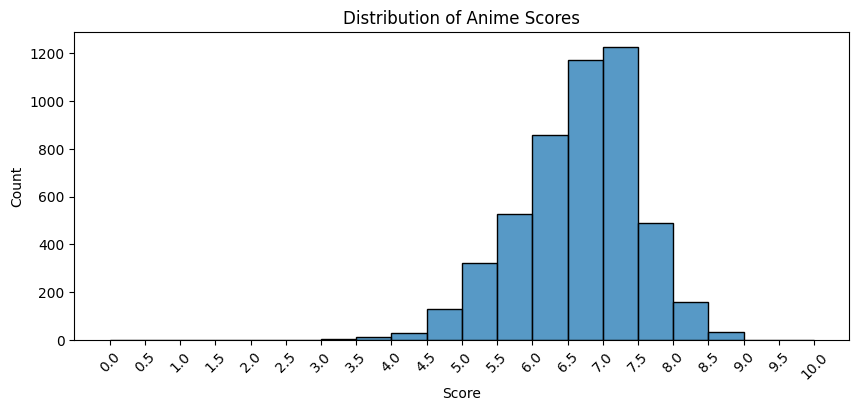

In [6]:

# 3. Analyze score distribution:
#    - mean
#    - median
#    - standard deviation
#    - histogram
print(anime_df['score'].describe())

scores = anime_df['score']
bins = np.arange(0, 10.5, 0.5)

plt.figure(figsize=(10, 4))

# sns.histplot(scores, bins=bins, kde=True)
sns.histplot(scores, bins=bins, kde=False)

plt.title("Distribution of Anime Scores")
plt.xlabel("Score")
plt.ylabel("Count")

plt.xticks(bins, rotation=45)

plt.show()

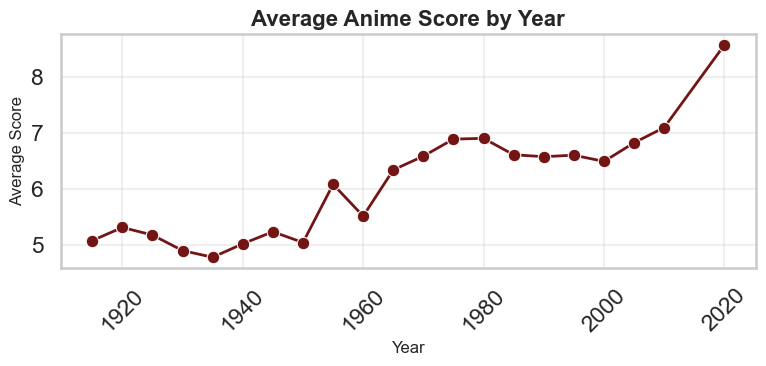

In [7]:
# 4. Analyze anime production by year.

years = anime_df['year']

# average scores by years (bins of 5)
anime_score_year = anime_df[['year', 'score']]
years_binned = pd.Series(years) // 5 * 5
anime_scores_binned = pd.concat((years_binned, anime_df['score']), axis=1)

# in 2020th no anime bcz didnt parse data enough yet
# sns.histplot(years, bins=np.arange(years.min(), years.max(), 5))


avg_score_by_years = (
    anime_scores_binned
    .groupby('year')
    .mean()
)

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=avg_score_by_years,
    x="year",
    y="score",
    marker="o",
    linewidth=2,
    color="#731515"
)

plt.title("Average Anime Score by Year", fontsize=16, weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Score", fontsize=12)

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# anime_scores_binned

# Results:
# there's a growing trend in number of animes (more animes each year)
# can see average score growth as year proceeds (does this mean that with time anime got better?)



In [8]:
# 5. Find the most common anime types:
#    TV, Movie, OVA, ONA, Special, etc.
(
    anime_df
    .groupby('type')['type']
    .count()
)


type
CM               3
Movie          832
Music           42
ONA             65
OVA           1711
PV               1
Special        319
TV            1860
TV Special     139
Name: type, dtype: int64

In [9]:
# 6. Find the most common source materials:
#    Manga, Original, Light Novel, Game, etc.
(
    anime_df
    .groupby('source')['source']
    .count()
    .sort_values(ascending=False)
)

source
Manga           1822
Original        1294
Visual novel     574
Unknown          354
Game             223
Light novel      204
Novel            197
Other            158
Book              51
4-koma manga      42
Picture book      23
Card game         10
Mixed media        8
Music              5
Web manga          4
Radio              3
Name: source, dtype: int64

<Axes: xlabel='episodes', ylabel='Count'>

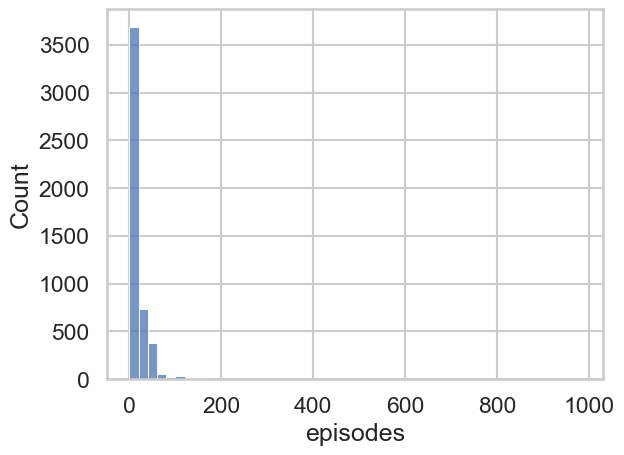

In [10]:
# 7. Analyze episode count distribution.
ep_min = anime_df['episodes'].min()
ep_max = anime_df['episodes'].max()
sns.histplot(anime_df['episodes'], bins=np.arange(ep_min, 1000, 20))


<Axes: xlabel='duration', ylabel='Count'>

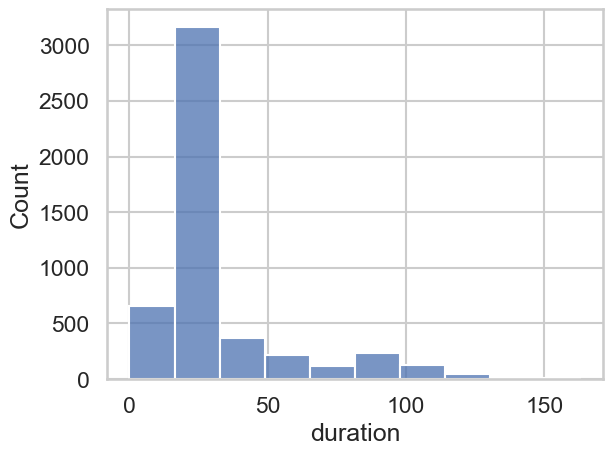

In [11]:
# 8. Analyze duration distribution.
duration = anime_df['duration']
sns.histplot(duration, bins=10)


In [12]:
# 9. Find anime with:
#    - highest score
hi_score = (
    anime_df
    .sort_values('score', ascending=False)[['title_english', 'score']]
    .iloc[0]
    .to_list()
)
print('Highest score: ', hi_score, sep='\n')

#    - lowest score
lo_score = (
    anime_df
    .sort_values('score', ascending=True)[['title_english', 'score']]
    .iloc[0]
    .to_list()
)
print('Lowest score: ', lo_score, sep='\n')

#    - most favorites
most_fav = (
    anime_df
    .sort_values('favorites', ascending=False)[['title_english', 'favorites']]
    .iloc[0]
    .to_list()
)
print('Most favorites: ', most_fav, sep='\n')

#    - most members
most_members = (
    anime_df
    .sort_values('members', ascending=False)[['title_english', 'members']]
    .iloc[0]
    .to_list()
)
print('Most members: ', most_members, sep='\n')


Highest score: 
['Fullmetal Alchemist: Brotherhood', np.float64(9.11)]
Lowest score: 
['Skelter Heaven', np.float64(1.89)]
Most favorites: 
['One Piece', np.int64(252104)]
Most members: 
['Death Note', np.int64(4300530)]


# GENRES / THEMES / DEMOGRAPHICS

In [13]:
# =========================
# GENRES / THEMES / DEMOGRAPHICS
# =========================
# problem: anime can have more than 1 genre
# how to split anime by genres? so that we have many anime rows that contain those genres
# 

# 10. Find the most common genres.
genres = anime_df['genres']
common_genres = (
    genres
    .explode()
    .value_counts()
    .iloc[:5]
)
common_genres


genres
Comedy       1728
Adventure    1350
Sci-Fi       1333
Action       1173
Drama        1082
Name: count, dtype: int64

In [14]:
# 11. Find the highest-rated genres.
(
    anime_df[['score', 'genres']]
    .explode('genres')
    .rename(columns={'genres': 'genre'})
    .groupby('genre')['score']
    .agg(
        avg_score="mean",
        count="size"
    )
    .sort_values('avg_score', ascending=False)
    .iloc[:10]
)

,avg_score,count
genre,,
Award Winning,7.363089,123
Suspense,7.328762,105
Mystery,7.141474,312
Slice of Life,7.074066,91
Sports,6.997730,185
Drama,6.993364,1082
Gourmet,6.992500,20
Romance,6.939452,803
Adventure,6.893467,1350


In [15]:
# 12. Find the most popular genres.
# ----- sum members - doesnt tell much about genre popularity, 
# it can be that its a lot animes with this genre
# ----- Avg members over count of animes with this genre
# will be more informative i think
(
    anime_df[['members', 'genres']]
    .explode('genres')
    .rename(columns={'genres': 'genre'})
    .groupby('genre')['members']
    .agg(
        anime_count='size',
        sum_members='sum'
    )
    .assign(ratio=lambda x: x['sum_members'] / x['anime_count'])
    .sort_values('ratio', ascending=False)
    .head()
)



,anime_count,sum_members,ratio
genre,,,
Suspense,105,31978612,304558.209524
Award Winning,123,36513581,296858.382114
Avant Garde,55,8388678,152521.418182
Supernatural,393,45527592,115846.290076
Mystery,312,35570045,114006.554487


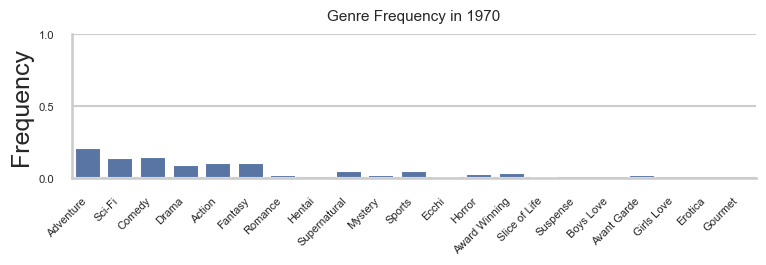

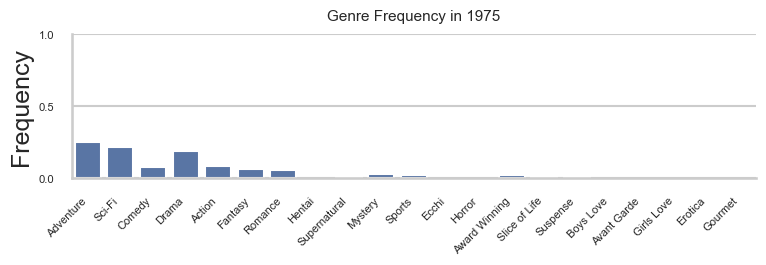

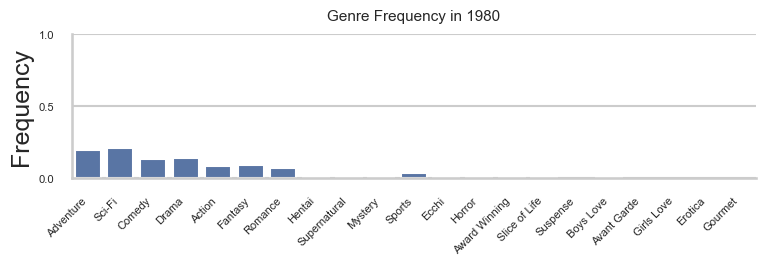

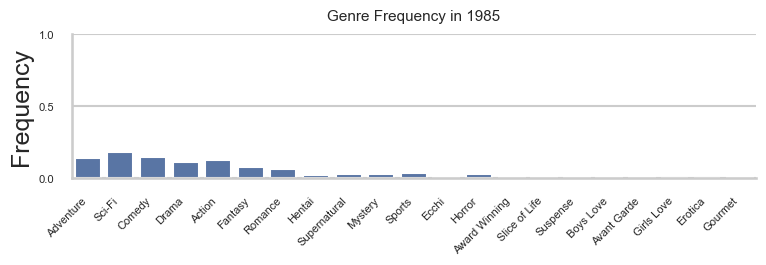

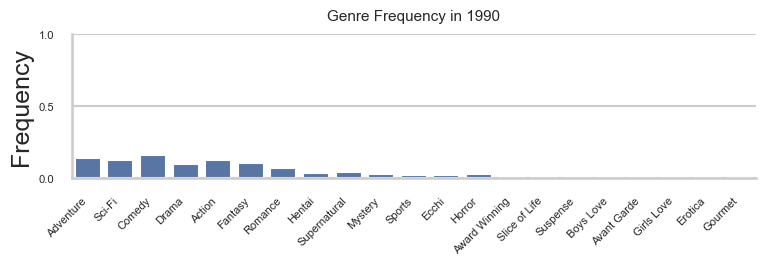

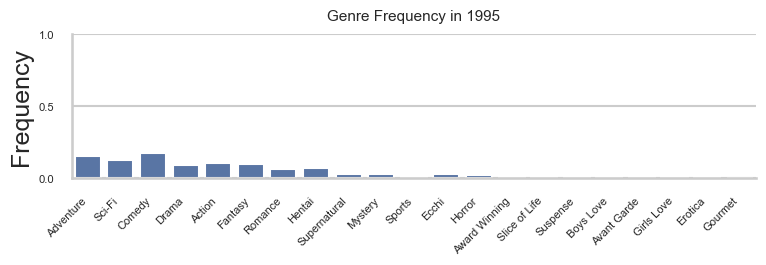

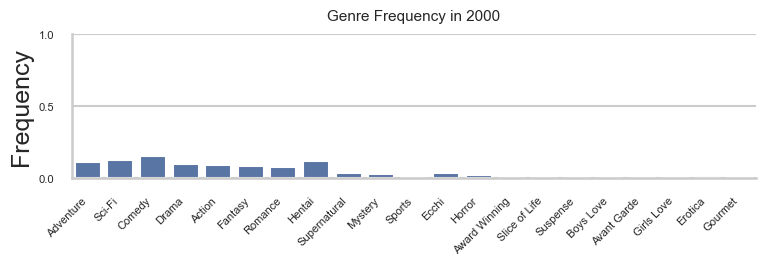

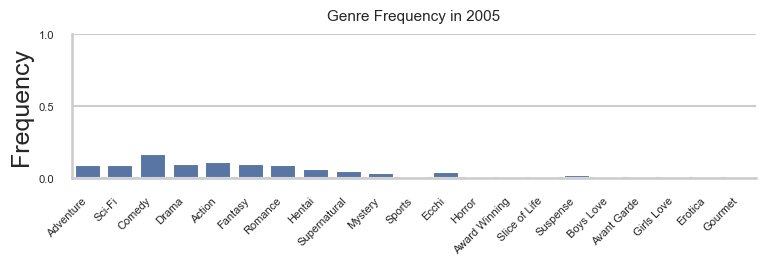

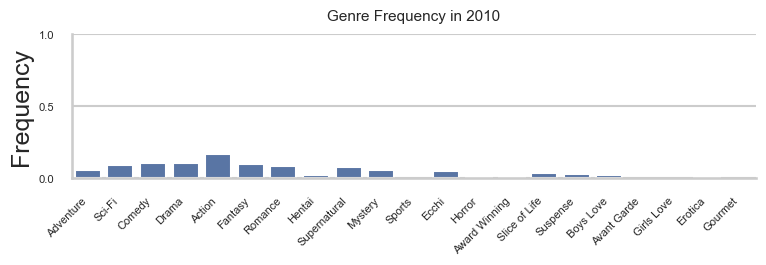

In [16]:
# 13. Analyze genre trends over time.
# count genres by year bins

genres_by_years = (
    anime_df[['year', 'genres']]
    .assign(year_bin=lambda x: x['year'] // 5 * 5)
    .explode('genres')
    .rename(columns={'genres': 'genre'})
    .groupby(['year_bin', 'genre'])
    .size()
    .reset_index(name='count')
    .sort_values(['year_bin', 'count'], ascending=[True, False])
    .groupby('year_bin')['genre']
    .agg(genres=list)['genres']
)



active_year_bins = (
    anime_df[['year']]
    .assign(year_bin=lambda x: x['year'] // 5 * 5)
    .groupby(['year_bin'])
    .agg(count=('year_bin', 'size'))
    .query('count > 50')
    .index
    .to_list()
)

active_years_genres = (
    anime_df[['year', 'genres']]
    .assign(year_bin=lambda x: x['year'] // 5 * 5)
    .explode('genres')
    .rename(columns={'genres': 'genre'})
    .loc[lambda s: s['year_bin'].isin(active_year_bins)]  # year_bin == active_year_bins
)

active_genre_counts = (
    anime_df[['year', 'genres']]
    .assign(year_bin=lambda x: x['year'] // 5 * 5)
    .explode('genres')
    .rename(columns={'genres': 'genre'})
    .loc[lambda s: s['year_bin'].isin(active_year_bins)]
    .groupby(['year_bin', 'genre'])
    .size()
    .reset_index(name='count')
)

total_genre_count_per_bin = (
    active_genre_counts
    .groupby('year_bin')['count']
    # .sum()
    .transform('sum')
)

# total_genre_count_per_bin
genre_frequencies = active_genre_counts.copy()
genre_frequencies['freq'] = genre_frequencies['count'] / total_genre_count_per_bin

genre_order = (
    genre_frequencies
    .groupby("genre")["freq"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# just checked if it worked correctly 
# (
#     genre_frequency
#     .groupby('year_bin')['freq']
#     .sum()
# )

sns.set_style("whitegrid")

for year, group in genre_frequencies.groupby("year_bin"):
    plt.figure(figsize=(8, 3))

    ax = sns.barplot(
        data=group,
        x="genre",
        y="freq",
        order=genre_order
    )

    ax.set_title(f"Genre Frequency in {year}", fontsize=11, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

    # 👇 key improvements
    plt.xticks(rotation=45, fontsize=8, ha="right")
    plt.yticks(fontsize=8)

    plt.ylim(0, 1)

    sns.despine()  # removes top/right borders → cleaner look

    plt.tight_layout()
    plt.show()

In [17]:
# 14. Find the most common themes.
common_themes = (
    anime_df['themes']
    .explode()
    .value_counts()
    .head(10)
)
common_themes


themes
Mecha            586
School           488
Historical       327
Military         289
Space            288
Adult Cast       225
Super Power      199
Martial Arts     160
Harem            153
Psychological    150
Name: count, dtype: int64

C:\Users\Artem\AppData\Local\Temp\ipykernel_9124\3778143918.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Artem\AppData\Local\Temp\ipykernel_9124\3778143918.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\Artem\AppData\Local\Temp\ipykernel_9124\3778143918.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Artem\AppData\Local\Temp\ipykernel_9124\3778143918.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

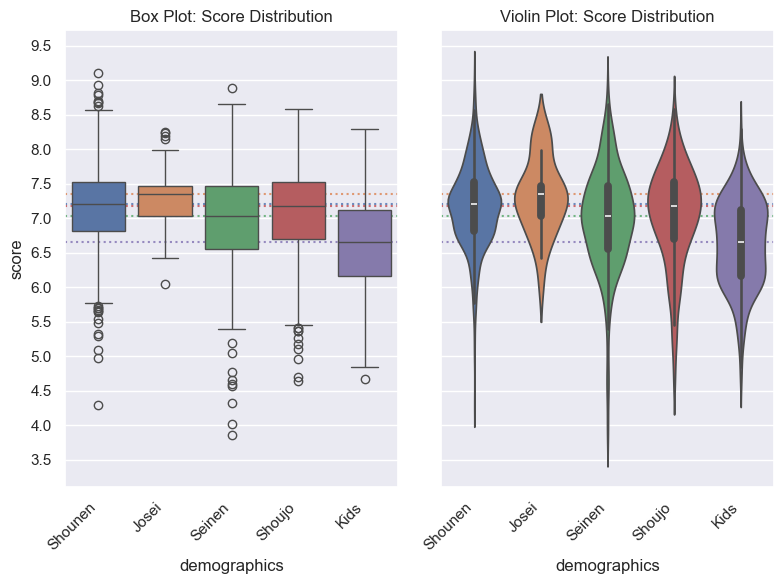

In [18]:
# 15. Compare score distributions between demographics:
#     Shounen, Seinen, Shoujo, Josei, etc.

demo_groups = (
    anime_df[['demographics', 'score']]
    .explode('demographics')
    .dropna()
    .groupby('demographics')
)
demo_scores = {demo: group['score'] for demo, group in demo_groups}

plot_data = anime_df.explode('demographics').dropna()
unique_demographics = plot_data['demographics'].unique()
medians = plot_data.groupby('demographics')['score'].median()
palette = sns.color_palette(n_colors=len(unique_demographics))
sns.set_theme()

fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharex=True, sharey=True)

# Left Plot: Box Plot
sns.boxplot(
    data=plot_data,
    x='demographics',
    y='score',
    palette=palette,  # Explicitly pass the palette so colors lock in perfectly
    ax=axes[0]
)
axes[0].set_title("Box Plot: Score Distribution")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Right Plot: Violin Plot
sns.violinplot(
    data=plot_data,
    x='demographics',
    y='score',
    palette=palette,  # Match the violin colors exactly
    ax=axes[1]
)
axes[1].set_title("Violin Plot: Score Distribution")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel("") 

# Set the y-axis intervals to 0.5
axes[0].yaxis.set_major_locator(ticker.MultipleLocator(0.5))

# 4. Loop through each demographic, find its color and median, and draw the line
for ax in axes:
    for i, demographic in enumerate(unique_demographics):
        median_val = medians[demographic]
        group_color = palette[i]  # Pull the matching color for this specific group
        
        ax.axhline(
            y=median_val, 
            color=group_color, 
            linestyle=':', 
            linewidth=1.5, 
            alpha=0.8,
            zorder=0  # Keeps the reference line behind the box/violin plots
        )

plt.tight_layout()
plt.show()


In [19]:
# 16. Analyze which demographics are most popular.
(
    anime_df[['demographics']]
    .explode('demographics')
    .groupby('demographics')
    .size()
    .sort_values(ascending=False)
)


demographics
Shounen    775
Seinen     365
Kids       297
Shoujo     243
Josei       29
dtype: int64

# Studio Analysis

In [20]:
# =========================
# STUDIO ANALYSIS
# =========================

# 17. Find the most productive studios.
# one anime can have more than 1 studio
# by productive means original work and collaborations?
(
    anime_df[['studios']]
    .explode('studios')
    .groupby('studios')
    .size()
    .sort_values(ascending=False)
)

anime_studio_count = (
    anime_df[['title_english', 'year', 'studios', 'score']]
    .assign(studios_count=lambda df: df['studios'].str.len().fillna(1).astype(int))
)

# foreach studio find min and max year of solo works
# and then find average animes every year
solo_animes = (
    anime_studio_count
    .query('studios_count == 1')
    .assign(studios=lambda s: s['studios'].str[0])
    .drop('studios_count', axis=1)
)

studio_lifespans = (
    solo_animes[['year', 'studios']]    
    .groupby('studios')['year']
    .agg(['min', 'max'])
    .assign(years_active=lambda s: s['max'] - s['min'])
    .sort_index()['years_active'] + 1
)

solo_counts = (
    solo_animes[['year', 'studios']]
    .groupby('studios')
    .size()
    .sort_index()
)

solo_productivity = solo_counts / studio_lifespans
solo_productivity.sort_values(ascending=False)


studios
Sunrise                   7.111111
Toei Animation            6.946429
J.C.Staff                     6.72
Madhouse                  5.944444
Gonzo                     5.833333
                            ...   
Oh! Production            0.148148
DAX Production            0.129032
Minami Machi Bugyousho         0.1
Animation Staff Room      0.076923
Tokyo Movie               0.066667
Length: 364, dtype: Float64

In [21]:
# 18. Find studios with highest average scores.
mean_score_studios = (
    anime_df[['studios', 'score']]
    .explode('studios')
    .groupby('studios')
    .mean()
    .sort_values('score', ascending=False)
)
mean_score_studios.head()


,score
studios,
K-Factory,8.403333
Nippon Ramayana Film,8.380000
Graphinica,8.340000
Khara,8.137500
8bit,7.830000


In [22]:
# 19. Find studios with highest average popularity.
(
    anime_df[['studios', 'members']]
    .explode('studios')
    .groupby('studios')
    .mean().astype(int)
    .sort_values('members', ascending=False)
    .reset_index()
    .head()
)


,studios,members
0,Graphinica,1020230
1,Manglobe,761856
2,P.A. Works,544114
3,Khara,533016
4,Bones,359282


Text(0.5, 0.98, 'Studio Performance Matrix: Scores, Members, and Favorites')

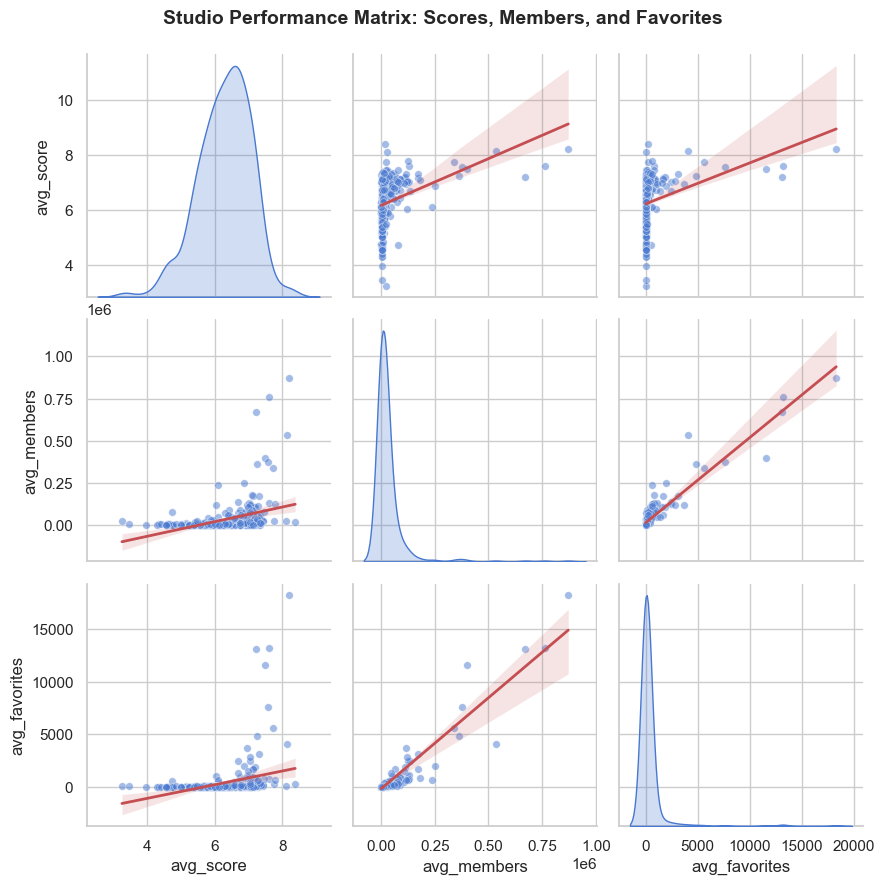

In [23]:
# 20. Analyze relationship between:
#     studio productivity vs average score.

solo_animes = (
    anime_df[['title_english', 'year', 'studios', 'score', 'members', 'favorites']]
    .assign(studios_count=lambda df: df['studios'].str.len().fillna(1).astype(int))
    .query('studios_count == 1')
    .assign(studios=lambda s: s['studios'].str[0])
    .drop('studios_count', axis=1)
)

s_mean_members = (
    solo_animes[['studios', 'members']]
    .groupby('studios')['members']
    .mean()
    .sort_index()
)

s_mean_favorites = (
    solo_animes[['studios', 'favorites']]
    .groupby('studios')['favorites']
    .mean()
    .sort_index()
)

s_mean_score = (
    solo_animes[['studios', 'score']]
    .groupby('studios')['score']
    .mean()
    .sort_index()
)

studio_analysis_df = pd.concat(
    {
        "avg_score": s_mean_score,
        "avg_members": s_mean_members,
        "avg_favorites": s_mean_favorites,
    },
    axis=1,
).dropna()

sns.set_theme(style="whitegrid", palette="muted")

g = sns.pairplot(
    data=studio_analysis_df,
    kind="reg",  # Adds linear regression lines + confidence intervals
    diag_kind="kde",  # Shows smooth distribution curves on the diagonal
    plot_kws={
        "scatter_kws": {
            "alpha": 0.5,
            "s": 30,
            "linewidths": 0.5,
            "edgecolor": "w",
        },
        "line_kws": {"color": "#C44E52", "linewidth": 2},
    },
    height=3,
)

# 4. Add clean titles and rendering configuration
g.figure.subplots_adjust(top=0.93)
g.figure.suptitle(
    "Studio Performance Matrix: Scores, Members, and Favorites",
    fontsize=14,
    fontweight="bold",
)



C:\Users\Artem\AppData\Local\Temp\ipykernel_9124\2670096445.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


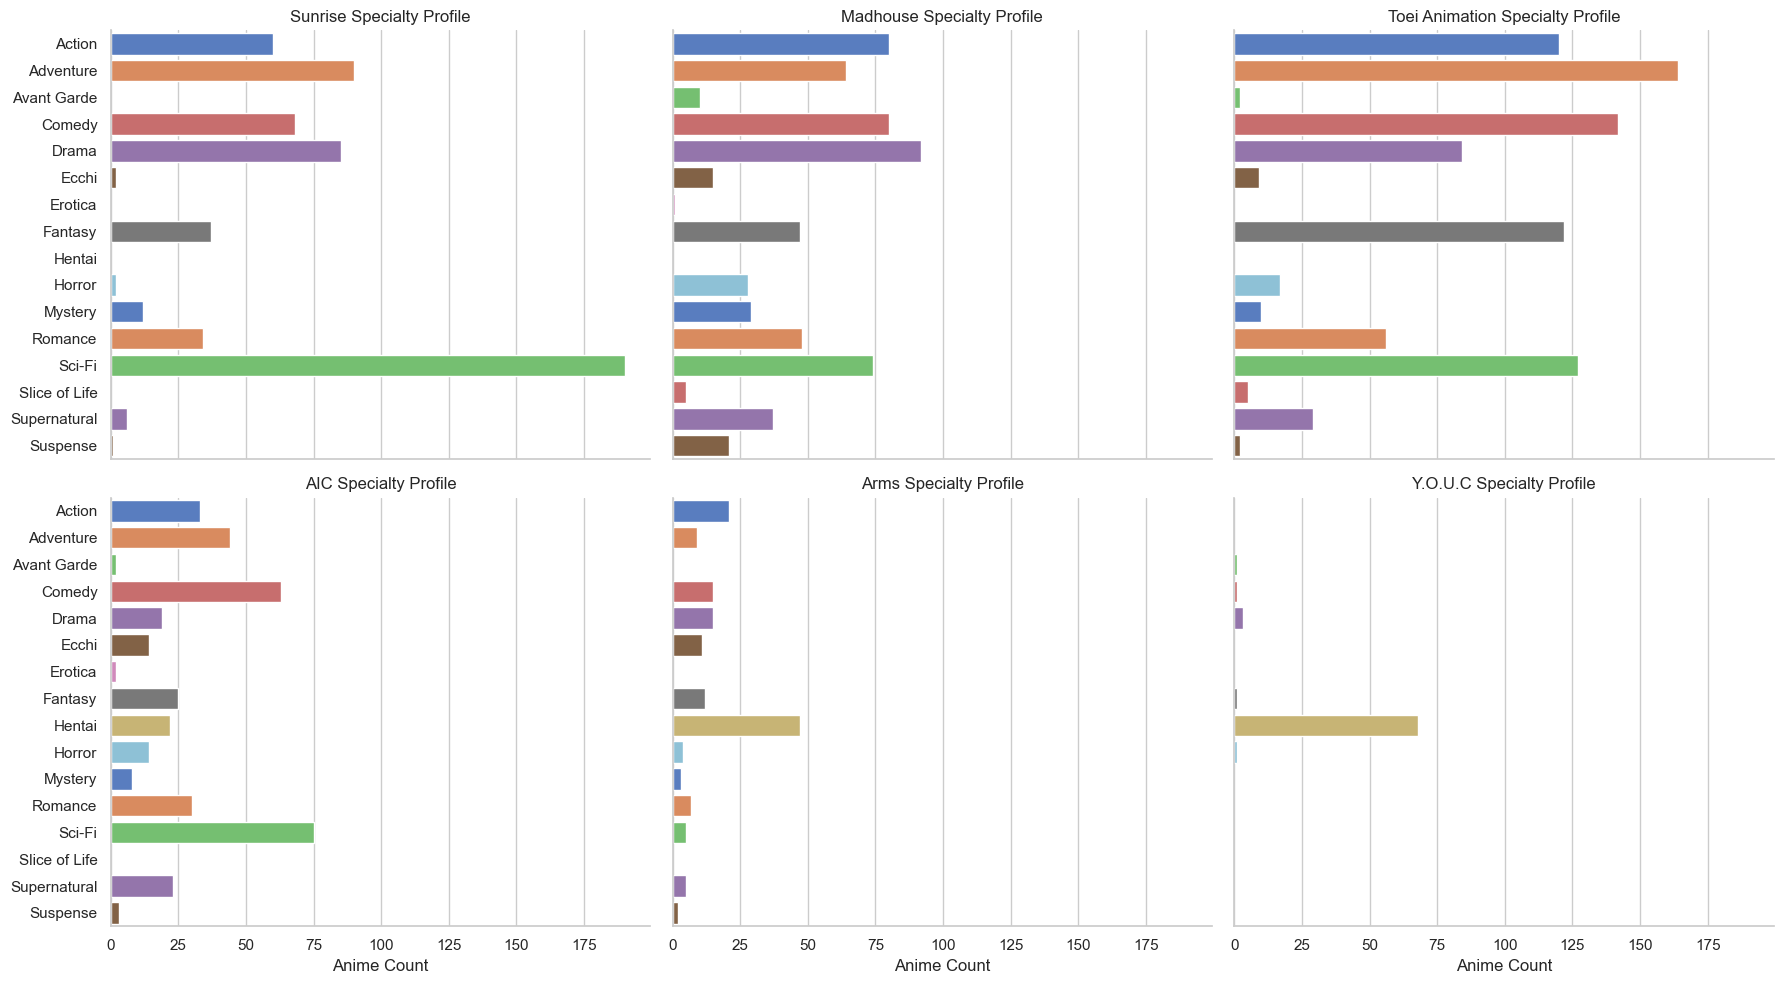

In [33]:
# 21. Find studios specializing in certain genres.

studios_i_want = ["Sunrise", "Madhouse", "Toei Animation", 'AIC', 'Arms', 'Y.O.U.C']
all_genres = (
    anime_df["genres"].explode().dropna().astype(str).unique()
)
excluded_genres = {"Award Winning", "Gourmet", "Sports", "Boys Love", "Girls Love"}
genres_i_want = list(set(all_genres) - excluded_genres)

# 3. Explode and filter
plot_data = (
    anime_df[["studios", "genres"]]
    .explode("studios")
    .explode("genres")
    .query("studios in @studios_i_want and genres in @genres_i_want")
    .dropna()
)

# 4. Plot using col_wrap so 6 studios don't squish into one infinite horizontal line
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=plot_data,
    y="genres",
    kind="count",
    col="studios",
    col_order=studios_i_want,
    order=sorted(genres_i_want),  # Alphabetical sorting makes comparisons easier
    col_wrap=3,  # Wraps the 6 studios into a clean 2x3 grid layout
    palette="muted",
    height=5,
    aspect=1.2,
)

g.set_titles("{col_name} Specialty Profile")
g.set_axis_labels("Anime Count", "")
plt.tight_layout()

plt.show()

In [37]:
hentai_studios = (
    anime_df[['studios', 'genres']]
    .explode('studios')
    .explode('genres')
    .dropna()
    .query('genres == "Hentai"')
    .groupby('studios')
    .size()
    .sort_values(ascending=False)
)

hentai_studios

studios
Y.O.U.C             68
Arms                47
T-Rex               28
Studio Jam          27
Triple X            25
                    ..
Sumomo Film          1
Twenty First         1
Tsubo Production     1
Tryforce             1
Zyc                  1
Length: 137, dtype: int64

# RELATIONSHIPS / CORRELATIONS


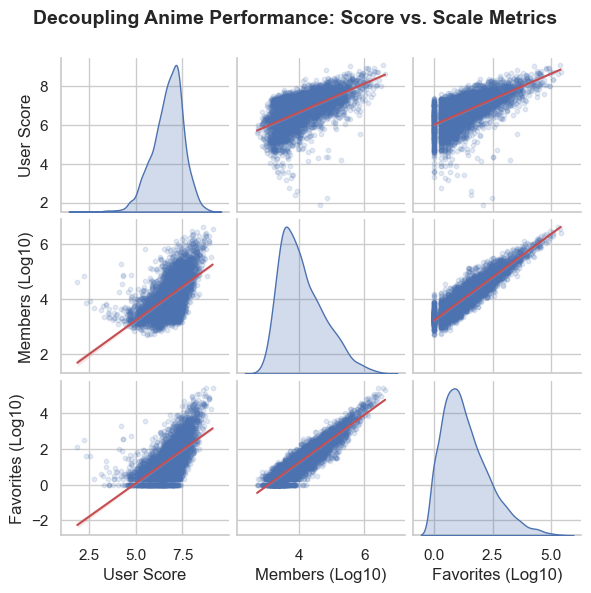

In [53]:
# =========================
# RELATIONSHIPS / CORRELATIONS
# =========================

# 22. Analyze correlation between:
#     score and popularity.

# 23. Analyze correlation between:
#     score and members.

# 24. Analyze correlation between:
#     favorites and score.

# 25. Analyze correlation between:
#     duration and score.

# 26. Analyze correlation between:
#     episode count and popularity.

# ===========================
plot_data = anime_df[["score", "members", "favorites"]].dropna().copy()

# Remove absolute zero entries to prevent log(0) math errors
plot_data = plot_data[(plot_data["members"] > 0) & (plot_data["favorites"] > 0)]

plot_data["log_members"] = np.log10(plot_data["members"])
plot_data["log_favorites"] = np.log10(plot_data["favorites"])

final_matrix_data = plot_data[["score", "log_members", "log_favorites"]]
sns.set_theme(style="whitegrid")

g = sns.pairplot(
    data=final_matrix_data,
    kind="reg",
    diag_kind="kde",
    plot_kws={
        "ci": 95,  # Explicitly requests the 95% confidence interval band
        "n_boot": 100,  # Fast bootstrapping so your notebook doesn't freeze
        "color": "#C44E52",
        "scatter_kws": {
            "alpha": 0.15,
            "s": 10,
            "color": "#4C72B0",
        },
        "line_kws": {
            "linewidth": 1.5,  # Keep your custom thickness here
        },
    },
    height=2,
)

g.axes[0, 0].set_ylabel("User Score")
g.axes[1, 0].set_ylabel("Members (Log10)")
g.axes[2, 0].set_ylabel("Favorites (Log10)")

g.axes[2, 0].set_xlabel("User Score")
g.axes[2, 1].set_xlabel("Members (Log10)")
g.axes[2, 2].set_xlabel("Favorites (Log10)")

g.figure.subplots_adjust(top=0.9)
g.figure.suptitle(
    "Decoupling Anime Performance: Score vs. Scale Metrics",
    fontsize=14,
    fontweight="bold",
)

plt.show()

# Advanced Analysis

In [ ]:
# =========================
# ADVANCED ANALYSIS
# =========================

# 27. Find underrated anime:
#     high score + low popularity.
# sort -> members, score (True, False)?
# The correct sorting strategy:

# criterion: members < 10000, score > 6.5
underrated_anime = (
    anime_df[['title_english', 'members', 'score']]
    .sort_values(by=["members", "score"], ascending=[True, False])
    .query('members < 10000 and score > 7.5')
)
underrated_anime

,title_english,members,score
2655,Energetic Bomb Ganbaruger,2183,7.56
3554,Galactic Gale Sasuraiger,2245,7.53
2945,Uchuusen Sagittarius,2343,7.52
2586,Time Quest,3147,7.64
2529,Juuni Senshi Bakuretsu Eto Ranger,3336,7.79
3457,Grimm's Fairy Tale Classics,3455,7.51
2756,Soar High! Isami,3494,7.68
2584,Mado King Granzort,3521,7.55
1262,Future GPX Cyber Formula Zero,3670,7.58
1264,Future GPX Cyber Formula Sin,3733,7.66


In [ ]:



# 28. Find overrated anime:
#     low score + very high popularity.

# 29. Analyze how anime scores changed over years.

# 30. Analyze whether Originals or Adaptations score higher.

# 31. Compare Movies vs TV series:
#     score, popularity, favorites, duration.

# 32. Find the most genre-diverse studios.

# 33. Analyze multi-genre anime:
#     do more genres correlate with popularity or score?

# 34. Analyze long-running anime separately.

# 35. Build a studio collaboration network.

# 36. Find niche genres with highest average scores.

# 37. Analyze trends in anime demographics over time.

# 38. Identify outliers in:
#     score, popularity, duration, episodes.

# 39. Compare old anime vs modern anime.

# 40. Build a simple recommendation similarity metric.
